In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib
import time

In [2]:
def generate_sample(n=3000, random_state=42):
    rng = np.random.RandomState(random_state)
    rows = []
    
    for _ in range(n):
        ambient_mag = rng.normal(0, 0.02)
        ambient_dist = rng.normal(5.0, 0.6)
        pir = 0
        camera_conf = rng.uniform(0.0, 0.2)
        label = 0
        
        event = rng.rand()
        if event < 0.12:  # Human
            pir = 1
            ambient_dist = rng.normal(1.2, 0.3)
            ambient_mag += rng.normal(0.05, 0.02)
            camera_conf = rng.uniform(0.6, 0.95)
            label = 1
            
        elif event < 0.20:  # Animal
            pir = rng.choice([0, 1], p=[0.3, 0.7])
            ambient_dist = rng.normal(2.0, 0.6)
            camera_conf = rng.uniform(0.3, 0.6)
            label = rng.choice([0, 1], p=[0.5, 0.5])
            
        elif event < 0.24:  # Vehicle
            pir = rng.choice([0, 1], p=[0.6, 0.4])
            ambient_dist = rng.normal(1.8, 0.8)
            ambient_mag += rng.normal(0.2, 0.08)
            camera_conf = rng.uniform(0.4, 0.85)
            label = 1
            
        ultrasonic = max(0.2, ambient_dist + rng.normal(0, 0.08))
        magnetic = ambient_mag + rng.normal(0, 0.005)
        camera_conf = np.clip(camera_conf + rng.normal(0, 0.04), 0, 1)
        
        rows.append({
            "pir": pir,
            "ultrasonic_m": ultrasonic,
            "magnetic_T": magnetic,
            "camera_conf": camera_conf,
            "label": label
        })
        
    return pd.DataFrame(rows)

In [3]:
df = generate_sample(3000, random_state=123)
df.sample(10)

,pir,ultrasonic_m,magnetic_T,camera_conf,label
467,0,4.346152,0.003426,0.082101,0
2302,1,1.378479,-0.018420,0.647454,1
1659,1,0.972075,0.096528,0.889287,1
2821,0,5.502804,0.002772,0.005677,0
2540,0,5.383468,0.020879,0.099582,0
2810,0,5.401256,-0.000473,0.015296,0
543,0,2.327814,0.279556,0.715919,1
1182,0,5.043157,-0.036454,0.000000,0
1816,1,2.462940,0.119965,0.601584,1
1523,1,1.353418,0.082268,0.743459,1


In [4]:
X = df[["pir", "ultrasonic_m", "magnetic_T", "camera_conf"]]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [5]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(n_estimators=150, random_state=42))
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


In [6]:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9626666666666667

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.97      0.98       595
           1       0.88      0.95      0.91       155

    accuracy                           0.96       750
   macro avg       0.93      0.96      0.94       750
weighted avg       0.96      0.96      0.96       750

Confusion Matrix:
 [[575  20]
 [  8 147]]


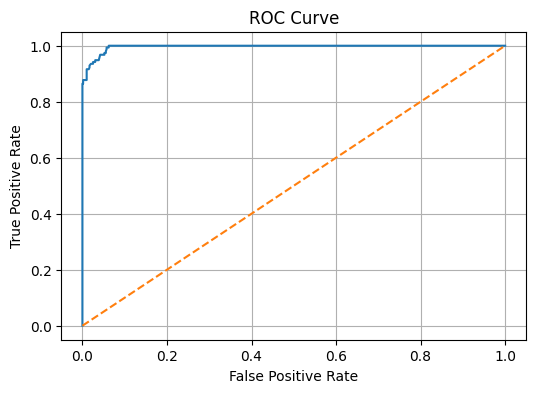

In [7]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.grid(True)
plt.show()

In [8]:
rf = pipeline.named_steps["rf"]
importances = rf.feature_importances_

pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values("Importance", ascending=False)

,Feature,Importance
3,camera_conf,0.425232
1,ultrasonic_m,0.348094
0,pir,0.147040
2,magnetic_T,0.079635


In [9]:
def rule_based_decision(row):
    if row["pir"] == 1 and (row["camera_conf"] > 0.5 or row["ultrasonic_m"] < 1.5):
        return 1
    if row["magnetic_T"] > 0.08:
        return 1
    return 0

rule_preds = X_test.apply(rule_based_decision, axis=1)

print("Rule-Based Accuracy:", accuracy_score(y_test, rule_preds))
print(classification_report(y_test, rule_preds))

Rule-Based Accuracy: 0.9653333333333334
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       595
           1       0.94      0.89      0.91       155

    accuracy                           0.97       750
   macro avg       0.96      0.94      0.95       750
weighted avg       0.96      0.97      0.96       750



In [10]:
import joblib

joblib.dump(pipeline, "sensitial_model.pkl")
print("Model saved as sensitial_model.pkl")

Model saved as sensitial_model.pkl


In [11]:
stream = generate_sample(10, random_state=999)

for i, row in stream.iterrows():
    print("\nSample", i+1)
    print(row)

    # Rule
    rule = rule_based_decision(row)
    print("Rule-Based:", "ALERT" if rule==1 else "No Alert")

    # ML
    ml_pred = pipeline.predict([row[["pir","ultrasonic_m","magnetic_T","camera_conf"]]])[0]
    ml_prob = pipeline.predict_proba([row[["pir","ultrasonic_m","magnetic_T","camera_conf"]]])[0][1]

    print("ML Model:", "ALERT" if ml_pred==1 else "No Alert", f"(p={ml_prob:.2f})")

    time.sleep(0.5)


Sample 1
pir             0.000000
ultrasonic_m    5.819844
magnetic_T     -0.000701
camera_conf     0.086473
label           0.000000
Name: 0, dtype: float64
Rule-Based: No Alert
ML Model: No Alert (p=0.00)


C:\Users\Nikky Sona\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Nikky Sona\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



Sample 2
pir             1.000000
ultrasonic_m    2.682655
magnetic_T     -0.044456
camera_conf     0.287501
label           1.000000
Name: 1, dtype: float64
Rule-Based: No Alert
ML Model: No Alert (p=0.29)


C:\Users\Nikky Sona\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Nikky Sona\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



Sample 3
pir             0.000000
ultrasonic_m    4.787934
magnetic_T      0.000365
camera_conf     0.070990
label           0.000000
Name: 2, dtype: float64
Rule-Based: No Alert
ML Model: No Alert (p=0.00)


C:\Users\Nikky Sona\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Nikky Sona\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



Sample 4
pir             0.000000
ultrasonic_m    4.418306
magnetic_T      0.002385
camera_conf     0.127549
label           0.000000
Name: 3, dtype: float64
Rule-Based: No Alert
ML Model: No Alert (p=0.00)


C:\Users\Nikky Sona\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Nikky Sona\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



Sample 5
pir             0.000000
ultrasonic_m    4.857662
magnetic_T     -0.005097
camera_conf     0.037870
label           0.000000
Name: 4, dtype: float64
Rule-Based: No Alert


C:\Users\Nikky Sona\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Nikky Sona\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


ML Model: No Alert (p=0.00)

Sample 6
pir             0.000000
ultrasonic_m    4.960578
magnetic_T      0.030787
camera_conf     0.168815
label           0.000000
Name: 5, dtype: float64
Rule-Based: No Alert


C:\Users\Nikky Sona\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Nikky Sona\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


ML Model: No Alert (p=0.00)

Sample 7
pir             0.000000
ultrasonic_m    5.479041
magnetic_T     -0.002819
camera_conf     0.235931
label           0.000000
Name: 6, dtype: float64
Rule-Based: No Alert


C:\Users\Nikky Sona\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Nikky Sona\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


ML Model: No Alert (p=0.00)

Sample 8
pir             0.000000
ultrasonic_m    6.031218
magnetic_T      0.032442
camera_conf     0.033719
label           0.000000
Name: 7, dtype: float64
Rule-Based: No Alert
ML Model: No Alert (p=0.00)


C:\Users\Nikky Sona\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Nikky Sona\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



Sample 9
pir             0.000000
ultrasonic_m    4.261743
magnetic_T      0.024968
camera_conf     0.099643
label           0.000000
Name: 8, dtype: float64
Rule-Based: No Alert


C:\Users\Nikky Sona\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Nikky Sona\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


ML Model: No Alert (p=0.00)

Sample 10
pir             0.000000
ultrasonic_m    5.065463
magnetic_T      0.039346
camera_conf     0.068854
label           0.000000
Name: 9, dtype: float64
Rule-Based: No Alert
ML Model: No Alert (p=0.00)


C:\Users\Nikky Sona\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Nikky Sona\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
